# Evaluate Optuna Hyperparameter Tuning

In [ ]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import optuna
import optuna.visualization as vis
import seaborn as sns
from IPython.display import clear_output, display
from ipywidgets import interact


In [2]:
study = optuna.load_study(
    study_name="flowmatching_20251029_2_hyperparameters_dev",
    storage="sqlite:///optuna_study.db"
)

print(f"Best value: {study.best_value:.06f}")
print("Best params:", study.best_params)
df = study.trials_dataframe()
df

Best value: 0.403045
Best params: {'MODEL_SIZE': 'S', 'step_size': 0.2, 'method': 'midpoint', 'batch_size_train': 64, 'lr': 0.003, 'weight_decay': 0.0, 'warmup_steps': 5000, 'halfcosine_steps': 80000, 'min_lr': 1.448612222179744e-07, 'max_lr': 0.8001606601982787}


,number,value,datetime_start,datetime_complete,duration,params_MODEL_SIZE,params_batch_size_train,params_halfcosine_steps,params_lr,params_max_lr,params_method,params_min_lr,params_step_size,params_warmup_steps,params_weight_decay,state
0,0,0.609852,2025-10-29 16:24:35.758501,2025-10-29 16:44:19.782661,0 days 00:19:44.024160,S,32,10000,0.0010,0.835145,midpoint,3.284852e-07,0.05,2000,0.00,COMPLETE
1,1,0.500346,2025-10-29 16:44:19.810881,2025-10-29 17:07:31.633442,0 days 00:23:11.822561,L,32,20000,0.0003,0.171071,midpoint,1.412375e-06,0.05,3500,0.10,COMPLETE
2,2,0.462496,2025-10-29 17:07:31.658655,2025-10-29 18:23:59.479840,0 days 01:16:27.821185,M,128,70000,0.0003,0.448664,midpoint,8.555089e-06,0.20,2000,0.00,COMPLETE
3,3,0.605009,2025-10-29 18:23:59.514022,2025-10-29 19:06:36.155257,0 days 00:42:36.641235,L,64,10000,0.0010,0.761521,euler,2.615882e-07,0.20,4500,0.01,COMPLETE
4,4,0.503860,2025-10-29 19:06:36.178794,2025-10-29 19:27:27.314300,0 days 00:20:51.135506,M,32,70000,0.0030,0.107479,euler,2.287177e-07,0.20,500,0.01,COMPLETE
5,5,0.621277,2025-10-29 19:27:27.347033,2025-10-29 20:06:42.282192,0 days 00:39:14.935159,M,64,70000,0.0010,0.342055,euler,1.944272e-07,0.05,2000,0.10,COMPLETE
6,6,0.667098,2025-10-29 20:06:42.310542,2025-10-29 20:26:50.410769,0 days 00:20:08.100227,S,32,90000,0.0001,0.170228,euler,6.887385e-06,0.10,500,0.01,COMPLETE
7,7,0.484545,2025-10-29 20:26:50.438094,2025-10-29 21:44:25.348415,0 days 01:17:34.910321,M,128,30000,0.0001,0.869704,midpoint,3.794825e-06,0.10,3000,0.10,COMPLETE
8,8,0.403045,2025-10-29 21:44:25.372429,2025-10-29 22:23:13.613630,0 days 00:38:48.241201,S,64,80000,0.0030,0.800161,midpoint,1.448612e-07,0.20,5000,0.00,COMPLETE
9,9,0.570350,2025-10-29 22:23:13.641276,2025-10-29 22:44:01.003031,0 days 00:20:47.361755,M,32,60000,0.0003,0.608557,euler,1.957612e-07,0.20,500,0.01,COMPLETE


### Filter Best Trials for specific parameters

In [3]:
@interact(model_size=["S", "M", "L"])
def show_best(model_size):
    best = (
        df[df["params_MODEL_SIZE"] == model_size]
        .sort_values("value")
        .head(3)
    )
    display(best)

interactive(children=(Dropdown(description='model_size', options=('S', 'M', 'L'), value='S'), Output()), _dom_…

In [4]:
@interact(model_size=["S", "M", "L"])
def show_shortest(model_size):
    shortest = (
        df[df["params_MODEL_SIZE"] == model_size]
        .sort_values("duration")
        .head(3)
    )
    display(shortest)

interactive(children=(Dropdown(description='model_size', options=('S', 'M', 'L'), value='S'), Output()), _dom_…

In [5]:
mask = df["params_MODEL_SIZE"] == "M"
subset = df[mask].sort_values("value", ascending=True)
best_M = subset.iloc[0]
print("Best MODEL_SIZE=M trial:")
print(best_M[["number", "value"] + [c for c in df.columns if c.startswith("params_")]])

Best MODEL_SIZE=M trial:
number                            2
value                      0.462496
params_MODEL_SIZE                 M
params_batch_size_train         128
params_halfcosine_steps       70000
params_lr                    0.0003
params_max_lr              0.448664
params_method              midpoint
params_min_lr              0.000009
params_step_size                0.2
params_warmup_steps            2000
params_weight_decay             0.0
Name: 2, dtype: object


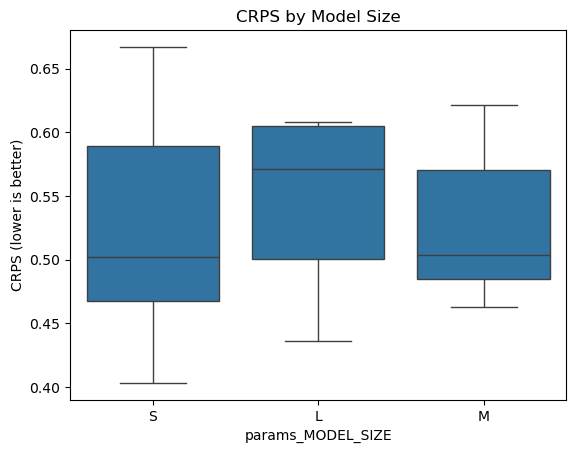

In [6]:
sns.boxplot(data=df, x="params_MODEL_SIZE", y="value")
plt.title("CRPS by Model Size")
plt.ylabel("CRPS (lower is better)")
plt.show()

In [7]:
best_per_size = (
    df.loc[df.groupby("params_MODEL_SIZE")["value"].idxmin(), ["params_MODEL_SIZE", "number", "value"]]
    .rename(columns={"value": "best_CRPS", "number": "trial_number"})
    .reset_index(drop=True)
)

print(best_per_size)

  params_MODEL_SIZE  trial_number  best_CRPS
0                 L            17   0.435859
1                 M             2   0.462496
2                 S             8   0.403045


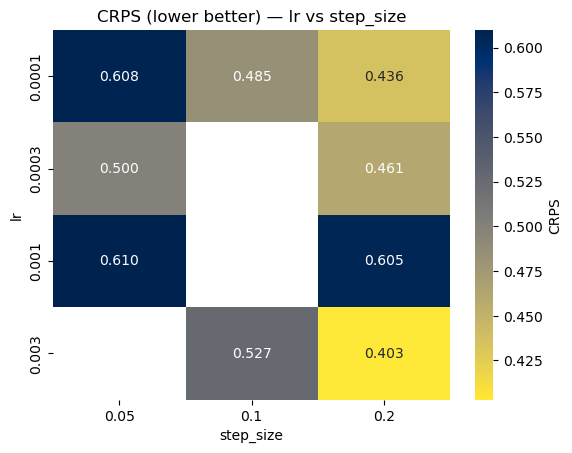

In [8]:
pivot = df.pivot_table(
    index="params_lr",
    columns="params_step_size",
    values="value",
    aggfunc="min"
)

sns.heatmap(pivot, annot=True, fmt=".3f", cmap="cividis_r", cbar_kws={'label': 'CRPS'})
plt.title("CRPS (lower better) — lr vs step_size")
plt.xlabel("step_size")
plt.ylabel("lr")
plt.show()

In [9]:
# vis.plot_param_importances(study)
# vis.plot_slice(study, params=["lr", "weight_decay"])

In [10]:
@interact(model_size=["S", "M", "L"])
def explore_model_size(model_size):
    subset = df[df["params_MODEL_SIZE"] == model_size].copy()
    subset = subset.sort_values("value").reset_index(drop=True)

    display(subset[[
        "number", "value", "params_batch_size_train", "params_lr",
        "params_weight_decay", "params_max_lr", "params_min_lr",
        "params_halfcosine_steps", "params_step_size", "params_warmup_steps",
        "params_method"
    ]])

    plt.figure(figsize=(6, 3))
    sns.barplot(data=subset, x="number", y="value", hue="params_method")
    plt.title(f"CRPS per Trial for MODEL_SIZE={model_size}")
    plt.ylabel("CRPS (lower is better)")
    plt.show()

interactive(children=(Dropdown(description='model_size', options=('S', 'M', 'L'), value='S'), Output()), _dom_…

In [26]:
# Round helper columns (if not already done)
df["params_min_lr_round"] = df["params_min_lr"].round(7)
df["params_max_lr_round"] = df["params_max_lr"].round(1)

# --- Define dropdown widgets ---
model_size_dd = widgets.Dropdown(options=sorted(df["params_MODEL_SIZE"].unique()), description="Model size")
step_size_dd = widgets.Dropdown(description="Step size")
method_dd = widgets.Dropdown(description="Method")
batch_size_dd = widgets.Dropdown(description="Batch size")
lr_dd = widgets.Dropdown(description="LR")
weight_decay_dd = widgets.Dropdown(description="Weight decay")
warmup_dd = widgets.Dropdown(description="Warmup steps")
halfcosine_dd = widgets.Dropdown(description="Halfcosine steps")
min_lr_dd = widgets.Dropdown(description="min LR")
max_lr_dd = widgets.Dropdown(description="max LR")

out = widgets.Output()

# --- Define update logic ---
def update_dropdowns(change=None):
    filtered = df.copy()

    # Filter step by step depending on what's selected
    if model_size_dd.value:
        filtered = filtered[filtered["params_MODEL_SIZE"] == model_size_dd.value]
    step_size_dd.options = sorted(filtered["params_step_size"].unique())

    if step_size_dd.value in step_size_dd.options:
        filtered = filtered[filtered["params_step_size"] == step_size_dd.value]
    method_dd.options = sorted(filtered["params_method"].unique())

    if method_dd.value in method_dd.options:
        filtered = filtered[filtered["params_method"] == method_dd.value]
    batch_size_dd.options = sorted(filtered["params_batch_size_train"].unique())

    if batch_size_dd.value in batch_size_dd.options:
        filtered = filtered[filtered["params_batch_size_train"] == batch_size_dd.value]
    lr_dd.options = sorted(filtered["params_lr"].unique())

    if lr_dd.value in lr_dd.options:
        filtered = filtered[filtered["params_lr"] == lr_dd.value]
    weight_decay_dd.options = sorted(filtered["params_weight_decay"].unique())

    if weight_decay_dd.value in weight_decay_dd.options:
        filtered = filtered[filtered["params_weight_decay"] == weight_decay_dd.value]
    warmup_dd.options = sorted(filtered["params_warmup_steps"].unique())
    halfcosine_dd.options = sorted(filtered["params_halfcosine_steps"].unique())
    min_lr_dd.options = sorted(filtered["params_min_lr_round"].unique())
    max_lr_dd.options = sorted(filtered["params_max_lr_round"].unique())

def show_results(change=None):
    filtered = df.copy()
    conditions = [
        ("params_MODEL_SIZE", model_size_dd.value),
        ("params_step_size", step_size_dd.value),
        ("params_method", method_dd.value),
        ("params_batch_size_train", batch_size_dd.value),
        ("params_lr", lr_dd.value),
        ("params_weight_decay", weight_decay_dd.value),
        ("params_warmup_steps", warmup_dd.value),
        ("params_halfcosine_steps", halfcosine_dd.value),
        ("params_min_lr_round", min_lr_dd.value),
        ("params_max_lr_round", max_lr_dd.value),
    ]
    for col, val in conditions:
        if val is not None:
            filtered = filtered[filtered[col] == val]

    with out:
        clear_output()
        if filtered.empty:
            display("⚠️ No trials match these parameters.")
        else:
            display(filtered.sort_values("value").head(10))

# --- Link updates ---
for dd in [model_size_dd, step_size_dd, method_dd, batch_size_dd, lr_dd,
           weight_decay_dd, warmup_dd, halfcosine_dd, min_lr_dd, max_lr_dd]:
    dd.observe(update_dropdowns, names="value")
    dd.observe(show_results, names="value")

# --- Initialize ---
update_dropdowns()
display(widgets.VBox([
    widgets.HBox([model_size_dd, step_size_dd, method_dd]),
    widgets.HBox([batch_size_dd, lr_dd, weight_decay_dd]),
    widgets.HBox([warmup_dd, halfcosine_dd]),
    widgets.HBox([min_lr_dd, max_lr_dd]),
    out
]))

### Even more (unnecessary) evaluation

In [11]:
@interact(step_size=[0.05, 0.1, 0.2])
def show_best(step_size):
    best = (
        df[df["params_step_size"] == step_size]
        .sort_values("value")
        .head(3)
    )
    display(best)

interactive(children=(Dropdown(description='step_size', options=(0.05, 0.1, 0.2), value=0.05), Output()), _dom…

In [12]:
@interact(method=["midpoint", "euler"])
def show_best(method):
    best = (
        df[df["params_method"] == method]
        .sort_values("value")
        .head(3)
    )
    display(best)

interactive(children=(Dropdown(description='method', options=('midpoint', 'euler'), value='midpoint'), Output(…

In [13]:
@interact(batch_size_train=[32, 64, 128])
def show_best(batch_size_train):
    best = (
        df[df["params_batch_size_train"] == batch_size_train]
        .sort_values("value")
        .head(3)
    )
    display(best)

interactive(children=(Dropdown(description='batch_size_train', options=(32, 64, 128), value=32), Output()), _d…

In [14]:
@interact(lr=[1e-4, 3e-4, 1e-3, 3e-3])
def show_best(lr):
    best = (
        df[df["params_lr"] == lr]
        .sort_values("value")
        .head(3)
    )
    display(best)

interactive(children=(Dropdown(description='lr', options=(0.0001, 0.0003, 0.001, 0.003), value=0.0001), Output…

In [15]:
@interact(weight_decay=[0.0, 0.01, 0.1])
def show_best(weight_decay):
    best = (
        df[df["params_weight_decay"] == weight_decay]
        .sort_values("value")
        .head(3)
    )
    display(best)

interactive(children=(Dropdown(description='weight_decay', options=(0.0, 0.01, 0.1), value=0.0), Output()), _d…

In [16]:
@interact(warmup_steps=np.arange(500, 5001, 500))
def show_best(warmup_steps):
    best = (
        df[df["params_warmup_steps"] == warmup_steps]
        .sort_values("value")
        .head(3)
    )
    display(best)

interactive(children=(Dropdown(description='warmup_steps', options=(np.int64(500), np.int64(1000), np.int64(15…

In [17]:
@interact(halfcosine_steps=np.arange(10000, 100001, 10000))
def show_best(halfcosine_steps):
    best = (
        df[df["params_halfcosine_steps"] == halfcosine_steps]
        .sort_values("value")
        .head(3)
    )
    display(best)

interactive(children=(Dropdown(description='halfcosine_steps', options=(np.int64(10000), np.int64(20000), np.i…

In [18]:
df["params_min_lr_round"] = df["params_min_lr"].round(7)

min_lr_list = [round(v * scale, 8) for scale in [1e-7, 1e-6, 1e-5] for v in np.arange(1, 10, 2)]

@interact(min_lr=min_lr_list)
def show_best(min_lr):
    best = (
        df[df["params_min_lr_round"] == round(min_lr, 7)]
        .sort_values("value")
        .head(3)
    )
    display(best)

interactive(children=(Dropdown(description='min_lr', options=(np.float64(1e-07), np.float64(3e-07), np.float64…

In [19]:
df["params_max_lr_round"] = df["params_max_lr"].round(1)

max_lr_rate = [round(v, 2) for v in np.arange(0.1, 1.01, 0.1)]
@interact(max_lr=max_lr_rate)
def show_best(max_lr):
    best = (
        df[df["params_max_lr_round"] == round(max_lr, 1)]
        .sort_values("value")
        .head(3)
    )
    display(best)

interactive(children=(Dropdown(description='max_lr', options=(np.float64(0.1), np.float64(0.2), np.float64(0.3…

In [20]:
# Precompute rounded helper columns for matching
df["params_min_lr_round"] = df["params_min_lr"].round(7)
df["params_max_lr_round"] = df["params_max_lr"].round(1)

# Define slider and dropdown options
model_sizes = ["S", "M", "L"]
step_sizes = [0.05, 0.1, 0.2]
methods = ["midpoint", "euler"]
batch_sizes = [32, 64, 128]
lrs = [1e-4, 3e-4, 1e-3, 3e-3]
weight_decays = [0.0, 0.01, 0.1]
warmup_steps = np.arange(500, 5001, 500)
halfcosine_steps = np.arange(10000, 100001, 10000)
min_lr_list = [round(v * scale, 8) for scale in [1e-7, 1e-6, 1e-5] for v in np.arange(1, 10, 2)]
max_lr_list = [round(v, 2) for v in np.arange(0.1, 1.01, 0.1)]

@interact(
    model_size=model_sizes,
    step_size=step_sizes,
    method=methods,
    batch_size_train=batch_sizes,
    lr=lrs,
    weight_decay=weight_decays,
    warmup_steps=warmup_steps,
    halfcosine_steps=halfcosine_steps,
    # min_lr=min_lr_list,
    # max_lr=max_lr_list,
)
def show_best_all(
    model_size, step_size, method, batch_size_train,
    lr, weight_decay, warmup_steps, halfcosine_steps,
    ): # min_lr, max_lr):

    # Filter progressively (only active constraints)
    filtered = df.copy()
    filtered = filtered[
        (filtered["params_MODEL_SIZE"] == model_size)
        & (filtered["params_step_size"] == step_size)
        & (filtered["params_method"] == method)
        & (filtered["params_batch_size_train"] == batch_size_train)
        & (filtered["params_lr"] == lr)
        & (filtered["params_weight_decay"] == weight_decay)
        & (filtered["params_warmup_steps"] == warmup_steps)
        & (filtered["params_halfcosine_steps"] == halfcosine_steps)
        # & (filtered["params_min_lr_round"] == round(min_lr, 7))
        # & (filtered["params_max_lr_round"] == round(max_lr, 1))
    ]

    if len(filtered) == 0:
        display("⚠️ No matching trials found for this combination.")
    else:
        display(filtered.sort_values("value").head(5))

interactive(children=(Dropdown(description='model_size', options=('S', 'M', 'L'), value='S'), Dropdown(descrip…